In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# Fonctions pour répondre à la question 2

In [2]:
def grille(Xmin, Xmax, Ymin, Ymax, Mx, My): # Pour être plus flexible 
    hx = (Xmax - Xmin) / (Mx + 1)
    hy = (Ymax - Ymin) / (My + 1)
    x = np.linspace(Xmin + hx, Xmax - hx, Mx)
    y = np.linspace(Ymin + hy, Ymax - hy, My)
    X, Y = np.meshgrid(x, y, indexing="ij")
    return hx, hy, x, y, X, Y

def Omega(X,Y,r,R): # Savoir quels points respectent les condi de Dirichlet
    dis = X**2 + Y**2
    return (r**2 < dis ) & (dis < R**2)

def Dirichlet(X,Y,r,R):
    dis = X**2 + Y**2
    g = np.zeros_like(X)
    g[dis >= R**2] = 1.0  
    g[dis <= r**2] = 0.0   
    return g

def alpha_xy(x, y):
    n = np.sqrt(x**2 + y**2)
    if n < 1e-12:
        return np.zeros_like(x), np.zeros_like(y)
    return x / n, y / n

def dérivées_premieres(U, hx, hy):
    DxU = np.zeros_like(U)
    DyU = np.zeros_like(U)
    DxU[1:-1, :] = (U[2:, :] - U[:-2, :]) / (2 * hx)  # Car la dérivée en U_0,j ou U_i,0 n'est pas définie.
    DyU[:, 1:-1] = (U[:, 2:] - U[:, :-2]) / (2 * hy)
    return DxU, DyU

def dérivées_secondes(U, hx, hy):
    DxxU = np.zeros_like(U)
    DyyU = np.zeros_like(U)
    DxxU[1:-1, :] = (U[2:, :] + U[:-2, :] - 2 * U[1:-1, :]) / (hx**2)
    DyyU[:, 1:-1] = (U[:, 2:] + U[:, :-2] - 2 * U[:, 1:-1]) / (hy**2)
    return DxxU, DyyU

def beta(DxU, DyU):
    return np.sign(DxU), np.sign(DyU)

def alpha(DxU, DyU, eps=1e-12):
    norm = np.sqrt(DxU**2 + DyU**2)
    norm = np.maximum(norm, eps)  # éviter division par 0
    return DxU / norm, DyU / norm

def vc(X, Y, a, r, R):
    dis = X**2 + Y**2
    s = np.pi * (dis - r**2) / (R**2 - r**2)
    return 1.0 - a * np.sin(s)

def uex(X, Y, r, R): 
    dis = X**2 + Y**2
    s = (np.pi/2) * (dis - r**2) / (R**2 - r**2)
    return np.sin(s)

def u_2(X,Y,r,R):
    return np.ones_like(X)

def deriv_uex(X, Y, r, R):
    dis = X**2 + Y**2
    Cst = (np.pi/2) / (R**2 - r**2)         
    s = Cst * (dis - r**2)
    Cst_x = 2*Cst*X
    Cst_y = 2*Cst*Y
    cos_s = np.cos(s)
    sin_s = np.sin(s)
    ux = cos_s * Cst_x
    uy = cos_s * Cst_y
    xx = 2*Cst
    yy = 2*Cst
    uxx = -sin_s * (Cst_x**2) + cos_s * xx
    uyy = -sin_s * (Cst_y**2) + cos_s * yy
    return ux, uy, uxx, uyy

def f_from_uex(X, Y, r, R, a, sigx, sigy, vs, kappa):
    vx = vc(X, Y, a, r, R)
    ux, uy, uxx, uyy = deriv_uex(X, Y, r, R)
    norm2_grad = np.sqrt(ux**2 + uy**2)         
    norm1_grad = np.abs(ux) + np.abs(uy)         
    f = -0.5*(sigx**2 * uxx + sigy**2 * uyy) - vx*ux + vs*norm2_grad - kappa*norm1_grad
    return f

def Indice(i,j,Mx):
    return i + j * Mx

In [3]:
def build_A_b_semismooth_XY(U_n, X, Y, hx, hy, Omega_mask, g, f, sigma_x, sigma_y, vs, kappa, a, r, R):
   Mx, My = U_n.shape
   N = Mx * My

   DxU, DyU = dérivées_premieres(U_n, hx, hy)
   ax, ay = alpha(DxU, DyU) 
   bx, by = beta(DxU, DyU) 
   vc_grid = vc(X, Y, a, r, R)

   A = sp.lil_matrix((N, N), dtype=float)
   b = np.zeros(N, dtype=float)

   for j in range(My):
      for i in range(Mx):
         I = Indice(i,j,Mx)
         if not Omega_mask[i,j]: # si en dehors de Oméga
            A[I,I] = 1
            b[I] = g[i,j] # le g est issu de Dirichlet(X,Y,r,R)
            continue
         
         else : 

            A[I,I] = (sigma_x**2 / (hx**2) ) + (sigma_y**2 / (hy**2) )

            if i < Mx-1 :
               if Omega_mask[i+1,j]:
                  A[I,I+1] = -0.5 * sigma_x**2 / (hx**2) + ((-vc_grid[i,j] + vs*ax[i,j] - kappa * bx[i,j]) / hx ) * 0.5
               else : 
                  b[I] = b[I] - (-0.5 * sigma_x**2 / (hx**2) + ((-vc_grid[i,j] + vs*ax[i,j] - kappa * bx[i,j]) / hx ) * 0.5) * g[i+1,j]

            if j < My-1 :
               if Omega_mask[i,j+1]:
                  A[I,I+Mx] = -0.5 * sigma_y**2 / (hy**2) + 0.5 * (vs*ay[i,j] - kappa * by[i,j]) / hy
               else : 
                  b[I] = b[I] - (-0.5 * sigma_y**2 / (hy**2) + 0.5 * (vs*ay[i,j] - kappa * by[i,j]) / hy) * g[i,j+1]

            if i > 0 :
               if Omega_mask[i-1,j]:
                  A[I,I-1] = -0.5 * sigma_x**2 / (hx**2) + ((vc_grid[i,j] - vs * ax[i,j] + kappa * bx[i,j]) / hx ) * 0.5
               else : 
                  b[I] = b[I] - (-0.5 * sigma_x**2 / (hx**2) + ((vc_grid[i,j] - vs * ax[i,j] + kappa * bx[i,j]) / hx ) * 0.5) * g[i-1,j]

            if j > 0 :
               if Omega_mask[i,j-1]:
                  A[I,I-Mx] = -0.5 * sigma_y**2 / (hy**2) - 0.5 * (vs*ay[i,j] - kappa * by[i,j]) / hy
               else : 
                  b[I] = b[I] - (-0.5 * sigma_y**2 / (hy**2) - 0.5 * (vs*ay[i,j] - kappa * by[i,j]) / hy) * g[i,j-1]

         b[I] = b[I] + f[i,j]
         
             
   return A.tocsr(), b 

In [4]:
def semi_smooth(Mx,My,Xmin,Xmax,Ymin,Ymax,r,R,sigma_x,sigma_y,vs,kappa,a,tol,ite_max,f):
    
    hx, hy, x, y, X, Y = grille(Xmin, Xmax, Ymin, Ymax, Mx, My)
    Omega_mask = Omega(X,Y,r,R)
    g = Dirichlet(X,Y,r,R)
    U = g.copy()

    for i in range(ite_max):

        A,b = build_A_b_semismooth_XY(U, X, Y, hx, hy, Omega_mask, g, f, sigma_x, sigma_y, vs, kappa, a, r, R)
        Utem = spla.spsolve(A, b)
        Utemp = Utem.reshape((Mx, My))
        Utemp[~Omega_mask] = g[~Omega_mask]

        if np.max(np.abs(Utemp - U)) < tol:
            return Utemp
        else : 
            U = Utemp

    return U

# Question 2a

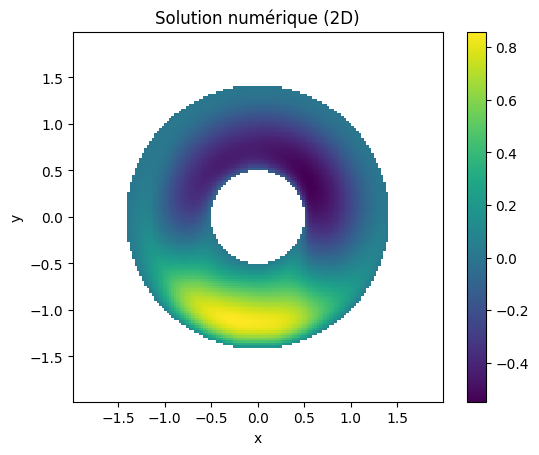

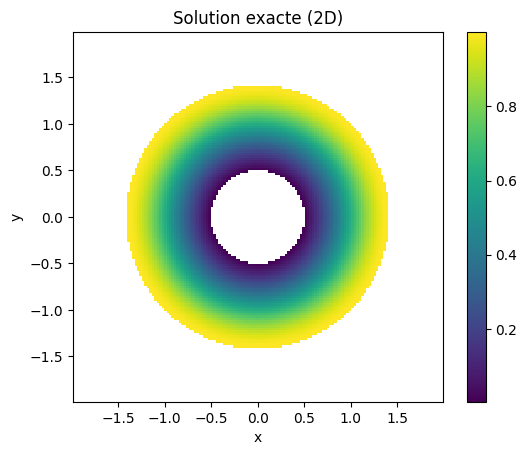

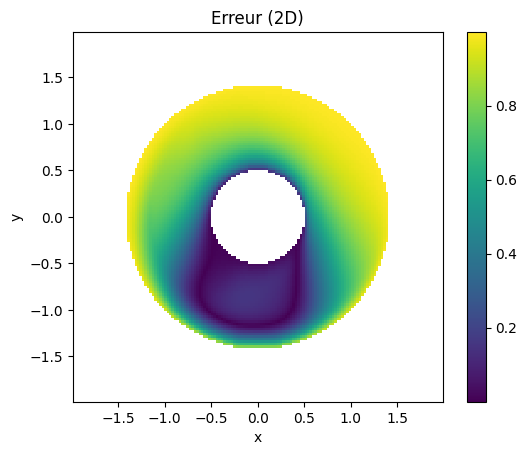

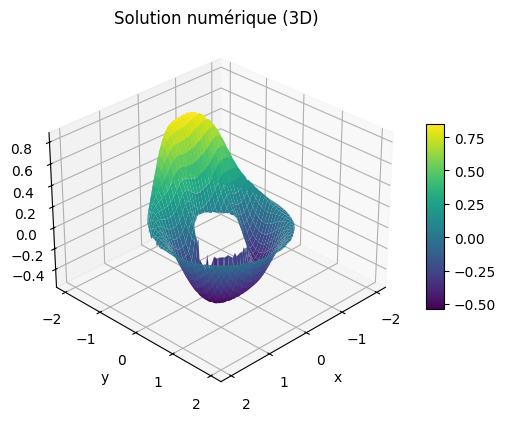

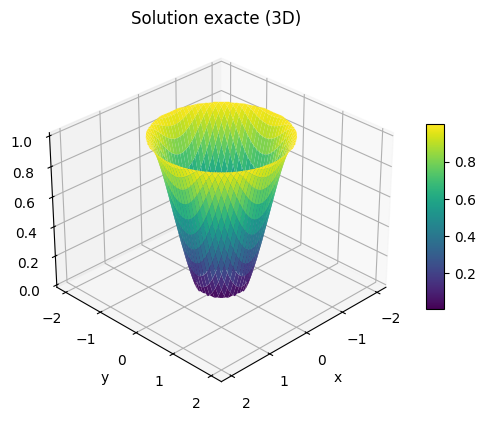

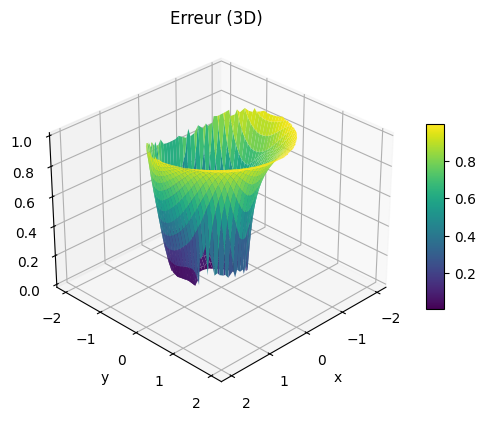

In [5]:

Xmin, Xmax = -2.0, 2.0
Ymin, Ymax = -2.0, 2.0

r = 0.5
R = np.sqrt(2.0)

kappa = 0.1
vs = 0.5
a = 0.2

sigma_x = 0.5
sigma_y = 0.2

tol = 1e-8
ite_max = 150

Mx = My = 150


def trace_solution(X, Y, U, Omega_mask=None, title="Solution"):
    Uplot = U.copy()
    if Omega_mask is not None:
        Uplot = np.where(Omega_mask, Uplot, np.nan)

    plt.figure()
    pcm = plt.pcolormesh(X, Y, Uplot, shading="auto")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.colorbar(pcm)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

def trace_solution_3D(X, Y, U, Omega_mask=None, title="Solution 3D"):
    Uplot = U.copy()
    if Omega_mask is not None:
        Uplot = np.where(Omega_mask, Uplot, np.nan)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(X, Y, Uplot,
                           cmap='viridis',
                           linewidth=0,
                           antialiased=True)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("U")
    ax.set_title(title)

    ax.view_init(elev=30, azim=45)  
    fig.colorbar(surf, shrink=0.5, aspect=10)

    plt.show()

hx, hy, x, y, X, Y = grille(Xmin, Xmax, Ymin, Ymax, Mx, My)
Omega_mask = Omega(X, Y, r, R)

f = f_from_uex(X, Y, r, R, a, sigma_x, sigma_y, vs, kappa)

U = semi_smooth(Mx, My, Xmin, Xmax, Ymin, Ymax,
                r, R, sigma_x, sigma_y, vs, kappa, a,
                tol, ite_max, f)

Uex = uex(X, Y, r, R)

trace_solution(X, Y, U, Omega_mask, title="Solution numérique (2D)")
trace_solution(X, Y, Uex, Omega_mask, title="Solution exacte (2D)")
trace_solution(X, Y, np.abs(U - Uex), Omega_mask, title="Erreur (2D)")


trace_solution_3D(X, Y, U, Omega_mask, title="Solution numérique (3D)")
trace_solution_3D(X, Y, Uex, Omega_mask, title="Solution exacte (3D)")
trace_solution_3D(X, Y, np.abs(U - Uex), Omega_mask, title="Erreur (3D)")

# Question 2B

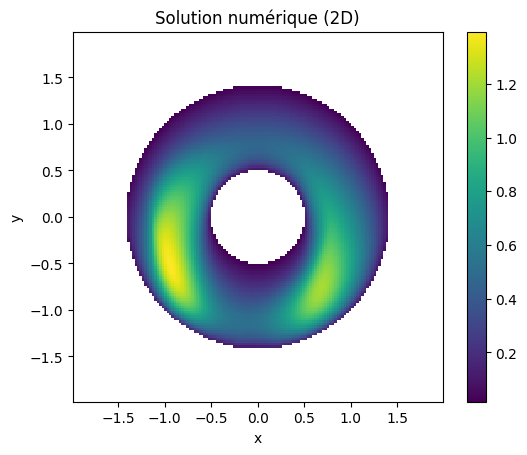

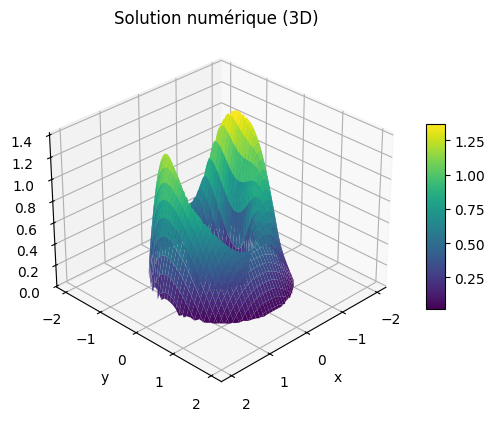

In [6]:
hx, hy, x, y, X, Y = grille(Xmin, Xmax, Ymin, Ymax, Mx, My)
Omega_mask = Omega(X, Y, r, R)

f2 = np.ones_like(X)

U = semi_smooth(Mx, My, Xmin, Xmax, Ymin, Ymax,
                r, R, sigma_x, sigma_y, vs, kappa, a,
                tol, ite_max, f2)


trace_solution(X, Y, U, Omega_mask, title="Solution numérique (2D)")



trace_solution_3D(X, Y, U, Omega_mask, title="Solution numérique (3D)")

In [7]:
import torch

help(torch.no_grad)

Help on class no_grad in module torch.autograd.grad_mode:

class no_grad(torch.utils._contextlib._NoParamDecoratorContextManager)
 |  no_grad(orig_func=None)
 |  
 |  Context-manager that disables gradient calculation.
 |  
 |  Disabling gradient calculation is useful for inference, when you are sure
 |  that you will not call :meth:`Tensor.backward()`. It will reduce memory
 |  consumption for computations that would otherwise have `requires_grad=True`.
 |  
 |  In this mode, the result of every computation will have
 |  `requires_grad=False`, even when the inputs have `requires_grad=True`.
 |  There is an exception! All factory functions, or functions that create
 |  a new Tensor and take a requires_grad kwarg, will NOT be affected by
 |  this mode.
 |  
 |  This context manager is thread local; it will not affect computation
 |  in other threads.
 |  
 |  Also functions as a decorator.
 |  
 |  .. note::
 |      No-grad is one of several mechanisms that can enable or
 |      disable